In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder, StandardScaler, RobustScaler, OrdinalEncoder
from sklearn.decomposition import PCA
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import f1_score
from sklearn.base import BaseEstimator, ClassifierMixin
from imblearn.over_sampling import BorderlineSMOTE
from collections import Counter

In [2]:
testing = pd.read_csv("dataset/UNSW_NB15_training-set.csv")
training = pd.read_csv("dataset/UNSW_NB15_testing-set.csv")
print(f"training dimensions: {training.shape}\n testing dimensions: {testing.shape}")
training.head()

training dimensions: (175341, 45)
 testing dimensions: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [3]:
training = training.drop(axis=1, columns=['id'])
testing = testing.drop(axis=1, columns=['id'])

training = training.dropna(subset=['attack_cat'])
testing = testing.dropna(subset=['attack_cat'])

categorical_features = list(training.select_dtypes(include=['object']).columns)
categorical_features.remove("attack_cat")
print(f"Categorical Features: {categorical_features}")

Categorical Features: ['proto', 'service', 'state']


In [4]:
# Combine and do a clean stratified 70/30 split
full_data = pd.concat([training, testing], ignore_index=True)

X_full = full_data.drop(columns=['attack_cat', 'label'])
y_full = full_data['attack_cat']

le = LabelEncoder()
y_encoded = le.fit_transform(y_full)
print(list(enumerate(le.classes_)))

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)
print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")

[(0, 'Analysis'), (1, 'Backdoor'), (2, 'DoS'), (3, 'Exploits'), (4, 'Fuzzers'), (5, 'Generic'), (6, 'Normal'), (7, 'Reconnaissance'), (8, 'Shellcode'), (9, 'Worms')]
Train size: (180371, 42), Test size: (77302, 42)


In [5]:
# --- Ordinal encode categoricals ---
oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_enc = X_train.copy()
X_test_enc  = X_test.copy()
X_train_enc[categorical_features] = oe.fit_transform(X_train[categorical_features])
X_test_enc[categorical_features]  = oe.transform(X_test[categorical_features])

# --- Feature Engineering ---
def add_features(df):
    df = df.copy()
    # Ratio features
    df['byte_ratio']     = df['sbytes'] / (df['dbytes'] + 1)
    df['pkt_ratio']      = df['spkts']  / (df['dpkts']  + 1)
    df['bytes_per_pkt']  = (df['sbytes'] + df['dbytes']) / (df['spkts'] + df['dpkts'] + 1)
    df['src_bytes_per_s']= df['sbytes'] / (df['dur'] + 1e-6)
    # Log transforms on heavy-tailed traffic features
    for col in ['dur', 'sbytes', 'dbytes', 'rate', 'sload', 'dload']:
        if col in df.columns:
            df[f'log_{col}'] = np.log1p(df[col].clip(lower=0))
    return df

X_train_eng = add_features(X_train_enc)
X_test_eng  = add_features(X_test_enc)

print(f"Features after engineering: {X_train_eng.shape[1]}")

Features after engineering: 52


In [16]:
# --- Clip outliers at 99th percentile (computed on train only) ---
numeric_cols = X_train_eng.select_dtypes(include=[np.number]).columns.tolist()
clip_upper = X_train_eng[numeric_cols].quantile(0.99)

X_train_clipped = X_train_eng.copy()
X_test_clipped  = X_test_eng.copy()
X_train_clipped[numeric_cols] = X_train_eng[numeric_cols].clip(upper=clip_upper, axis=1)
X_test_clipped[numeric_cols]  = X_test_eng[numeric_cols].clip(upper=clip_upper, axis=1)

# --- RobustScaler (median/IQR - more resilient to remaining outliers) ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clipped)
X_test_scaled  = scaler.transform(X_test_clipped)

print(f"Scaling complete. Train shape: {X_train_scaled.shape}")

C:\Users\cliff\AppData\Local\Temp\ipykernel_20128\3395518452.py:7: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train_clipped[numeric_cols] = X_train_eng[numeric_cols].clip(upper=clip_upper, axis=1)
C:\Users\cliff\AppData\Local\Temp\ipykernel_20128\3395518452.py:8: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_down

Scaling complete. Train shape: (180371, 52)


In [17]:
class_counts = Counter(y_train)
for i, count in sorted(class_counts.items()):
    print(f"Class {le.inverse_transform([i])[0]}: {count} samples")

Class Analysis: 1874 samples
Class Backdoor: 1630 samples
Class DoS: 11447 samples
Class Exploits: 31167 samples
Class Fuzzers: 16972 samples
Class Generic: 41210 samples
Class Normal: 65100 samples
Class Reconnaissance: 9791 samples
Class Shellcode: 1058 samples
Class Worms: 122 samples


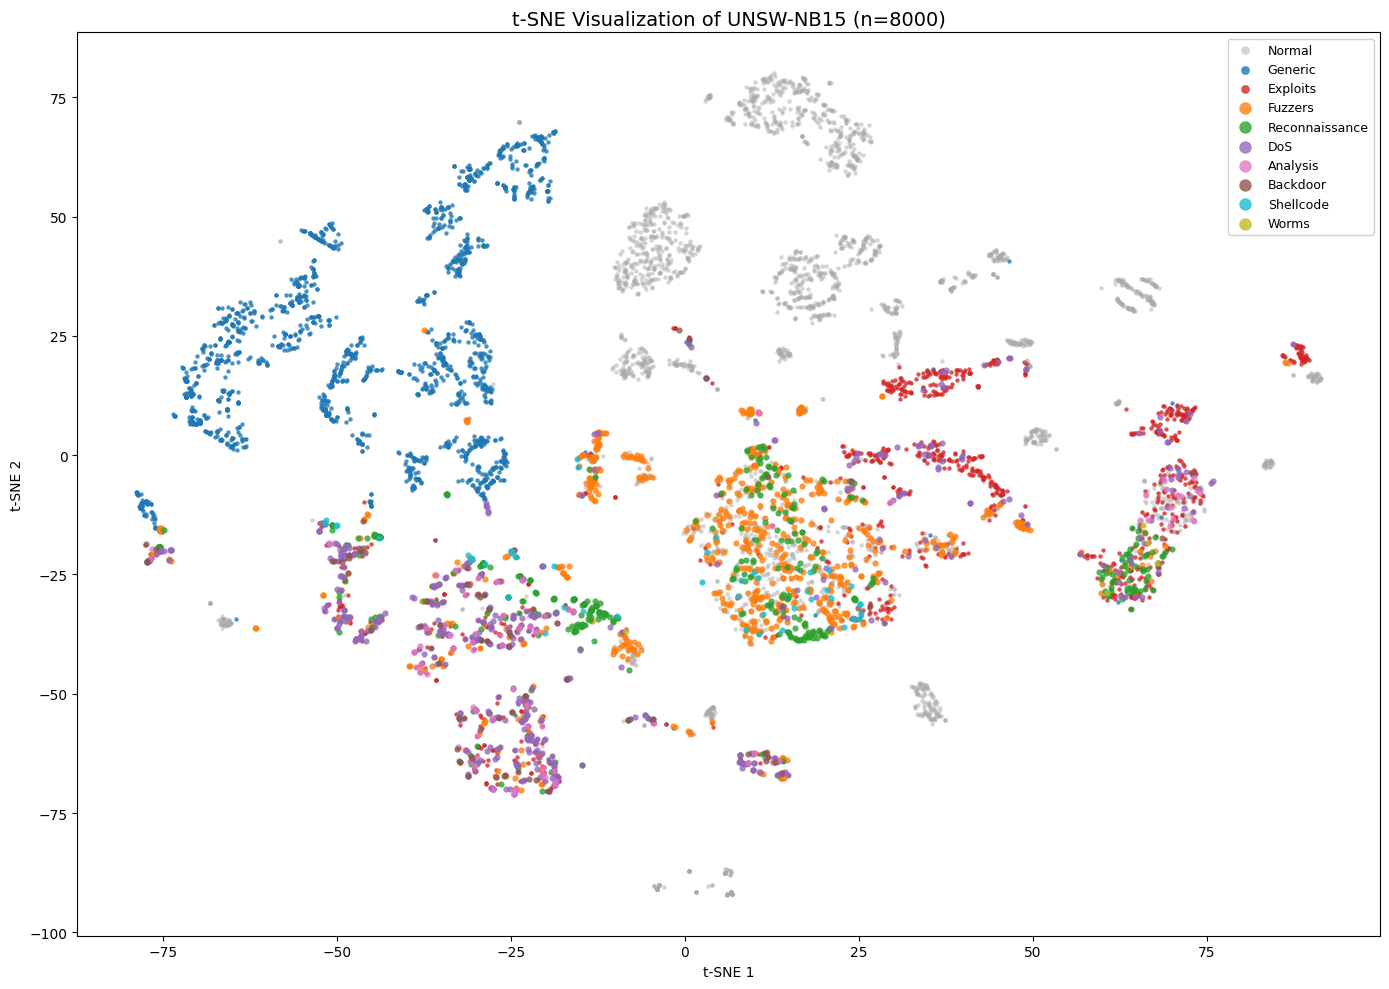

In [22]:
from sklearn.manifold import TSNE
import matplotlib.patches as mpatches

# t-SNE is slow on large datasets — sample a manageable subset
# keeping class proportions with stratify
sample_size = 8000
idx = []
for cls in np.unique(y_train):
    cls_idx = np.where(y_train == cls)[0]
    n = max(1, int(sample_size * len(cls_idx) / len(y_train)))
    idx.extend(np.random.choice(cls_idx, n, replace=False))

X_sample = X_train_scaled[idx]
y_sample = y_train[idx]

# Fit t-SNE
tsne = TSNE(n_components=2, perplexity=40, random_state=42, n_jobs=-1)
X_embedded = tsne.fit_transform(X_sample)

# Color mapping — Normal gets a distinct neutral color, attacks get vivid colors
color_map = {
    'Normal':         '#aaaaaa',   # grey — stands out as background
    'Generic':        '#1f77b4',   # blue
    'Exploits':       '#d62728',   # red
    'Fuzzers':        '#ff7f0e',   # orange
    'Reconnaissance': '#2ca02c',   # green
    'DoS':            '#9467bd',   # purple
    'Analysis':       '#e377c2',   # pink
    'Backdoor':       '#8c564b',   # brown
    'Shellcode':      '#17becf',   # cyan
    'Worms':          '#bcbd22',   # yellow-green
}

# Plot
fig, ax = plt.subplots(figsize=(14, 10))

for cls_name, color in color_map.items():
    cls_idx = le.transform([cls_name])[0]
    mask = y_sample == cls_idx
    ax.scatter(
        X_embedded[mask, 0],
        X_embedded[mask, 1],
        c=color,
        label=cls_name,
        alpha=0.5 if cls_name == 'Normal' else 0.8,
        s=10 if cls_name in ['Normal', 'Generic', 'Exploits'] else 20,
        linewidths=0
    )

ax.set_title('t-SNE Visualization of UNSW-NB15 (n=8000)', fontsize=14)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(
    loc='upper right',
    markerscale=2,
    framealpha=0.9,
    fontsize=9
)
plt.tight_layout()
plt.show()

In [18]:
# BorderlineSMOTE focuses synthetic samples near the decision boundary,
# which helps Analysis and Backdoor that sit close to Exploits/DoS.
sampling_strategy_new2 = {
    0: 4000,   # Analysis        — boost from ~1874
    1: 4000,   # Backdoor        — boost from ~1630
    2: 18000,   # DoS
    3: 31167,   # Exploits
    4: 18154,   # Fuzzers
    7: 15000,   # Reconnaissance
    8: 3500,    # Shellcode
}

smote = BorderlineSMOTE(sampling_strategy=sampling_strategy_new2, k_neighbors=5, random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Before SMOTE: {X_train_scaled.shape}")
print(f"After  SMOTE: {X_train_smote.shape}")

class_counts_after = Counter(y_train_smote)
for i, count in sorted(class_counts_after.items()):
    print(f"  {le.inverse_transform([i])[0]}: {count}")

Before SMOTE: (180371, 52)
After  SMOTE: (200253, 52)
  Analysis: 4000
  Backdoor: 4000
  DoS: 18000
  Exploits: 31167
  Fuzzers: 18154
  Generic: 41210
  Normal: 65100
  Reconnaissance: 15000
  Shellcode: 3500
  Worms: 122


In [19]:
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_smote)

In [20]:
xgb_model = XGBClassifier(
    n_estimators=1000,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=1,
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    objective='multi:softmax',
    num_class=len(le.classes_),
    early_stopping_rounds=30,
    gamma=1,
    reg_alpha=0.1,
    reg_lambda=1.5
)

xgb_model.fit(
    X_train_smote, y_train_smote,
    sample_weight=sample_weights,
    eval_set=[(X_test_scaled, y_test)],
)

y_pred = xgb_model.predict(X_test_scaled)
macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"Macro F1: {macro_f1:.4f}")
print(classification_report(y_test, y_pred, target_names=le.classes_))

[0]	validation_0-mlogloss:2.13385
[1]	validation_0-mlogloss:1.99861
[2]	validation_0-mlogloss:1.88663
[3]	validation_0-mlogloss:1.79038
[4]	validation_0-mlogloss:1.70644
[5]	validation_0-mlogloss:1.63117
[6]	validation_0-mlogloss:1.56361
[7]	validation_0-mlogloss:1.50256
[8]	validation_0-mlogloss:1.44649
[9]	validation_0-mlogloss:1.39534
[10]	validation_0-mlogloss:1.34819
[11]	validation_0-mlogloss:1.30453
[12]	validation_0-mlogloss:1.26439
[13]	validation_0-mlogloss:1.22687
[14]	validation_0-mlogloss:1.19198
[15]	validation_0-mlogloss:1.15909
[16]	validation_0-mlogloss:1.12809
[17]	validation_0-mlogloss:1.09908
[18]	validation_0-mlogloss:1.07174
[19]	validation_0-mlogloss:1.04594
[20]	validation_0-mlogloss:1.02167
[21]	validation_0-mlogloss:0.99891
[22]	validation_0-mlogloss:0.97720
[23]	validation_0-mlogloss:0.95651
[24]	validation_0-mlogloss:0.93713
[25]	validation_0-mlogloss:0.91885
[26]	validation_0-mlogloss:0.90148
[27]	validation_0-mlogloss:0.88512
[28]	validation_0-mlogloss:0.8

In [21]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

                precision    recall  f1-score   support

      Analysis       0.11      0.19      0.14       803
      Backdoor       0.08      0.15      0.10       699
           DoS       0.36      0.73      0.48      4906
      Exploits       0.86      0.55      0.67     13358
       Fuzzers       0.57      0.81      0.67      7274
       Generic       1.00      0.98      0.99     17661
        Normal       0.98      0.83      0.89     27900
Reconnaissance       0.85      0.81      0.83      4196
     Shellcode       0.49      0.85      0.62       453
         Worms       0.52      0.88      0.65        52

      accuracy                           0.79     77302
     macro avg       0.58      0.68      0.60     77302
  weighted avg       0.86      0.79      0.81     77302



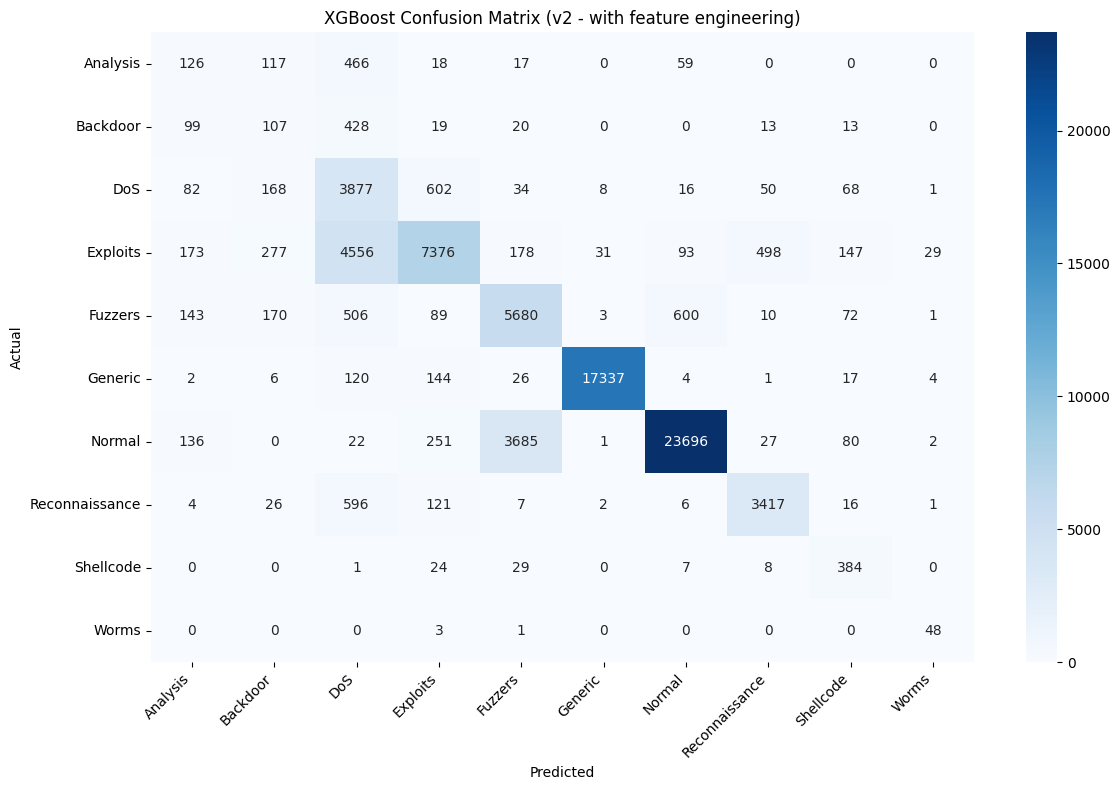

In [11]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix (v2 - with feature engineering)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

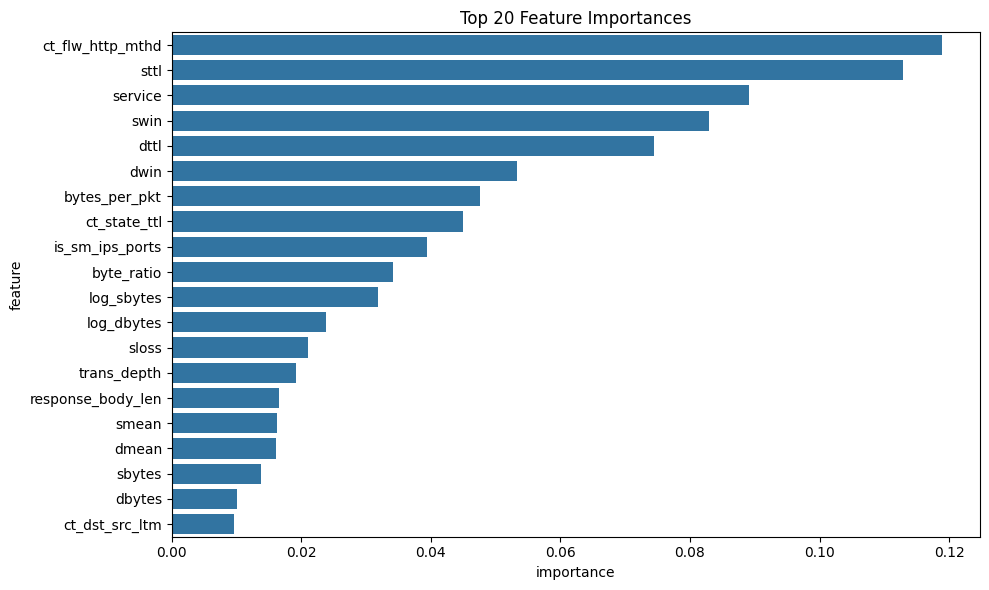

In [12]:
# Feature importance — useful to check if engineered features are pulling weight
feature_names = list(X_train_eng.columns)
importances = xgb_model.feature_importances_
feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_df, x='importance', y='feature')
plt.title('Top 20 Feature Importances')
plt.tight_layout()
plt.show()

In [13]:
cm_df = pd.DataFrame(cm, index=le.classes_, columns=le.classes_)

print("Analysis predicted as:")
print(cm_df.loc['Analysis'].sort_values(ascending=False))
print("\nBackdoor predicted as:")
print(cm_df.loc['Backdoor'].sort_values(ascending=False))
print("\nDoS predicted as:")
print(cm_df.loc['DoS'].sort_values(ascending=False))

Analysis predicted as:
DoS               466
Analysis          126
Backdoor          117
Normal             59
Exploits           18
Fuzzers            17
Generic             0
Reconnaissance      0
Shellcode           0
Worms               0
Name: Analysis, dtype: int64

Backdoor predicted as:
DoS               428
Backdoor          107
Analysis           99
Fuzzers            20
Exploits           19
Reconnaissance     13
Shellcode          13
Generic             0
Normal              0
Worms               0
Name: Backdoor, dtype: int64

DoS predicted as:
DoS               3877
Exploits           602
Backdoor           168
Analysis            82
Shellcode           68
Reconnaissance      50
Fuzzers             34
Normal              16
Generic              8
Worms                1
Name: DoS, dtype: int64
